In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Class Distribution of Target Variable (Heart_Risk) ###

Heart_Risk
0    35000
1    35000
Name: count, dtype: int64


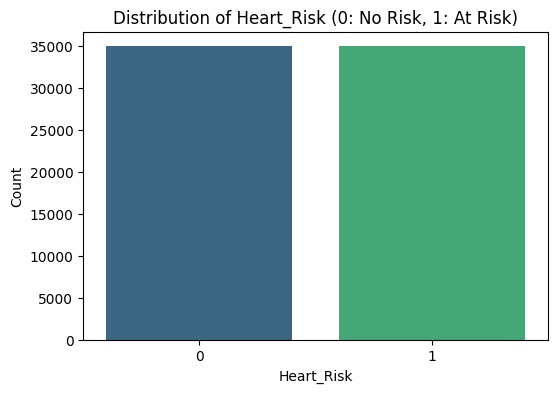



### 2. Correlation with Target Variable (Heart_Risk) ###

Top 10 features positively correlated with Heart_Risk:

Heart_Risk_Encoded     1.000000
Age                    0.605182
Pain_Arms_Jaw_Back     0.601403
Cold_Sweats_Nausea     0.601093
Dizziness              0.600202
Chest_Pain             0.599944
Fatigue                0.599260
Swelling               0.599173
Shortness_of_Breath    0.598772
Palpitations           0.596773
Name: Heart_Risk_Encoded, dtype: float64

Top 10 features negatively correlated with Heart_Risk:

Gender                 0.293609
Diabetes               0.396086
Family_History         0.397604
Smoking                0.398007
Obesity                0.399229
Chronic_Stress         0.401914
High_BP                0.404462
Sedentary_Lifestyle    0.404696
High_Cholesterol       0.405001
Palpitations           0.596773
Name: Heart_Risk_Encoded, dtype: float64


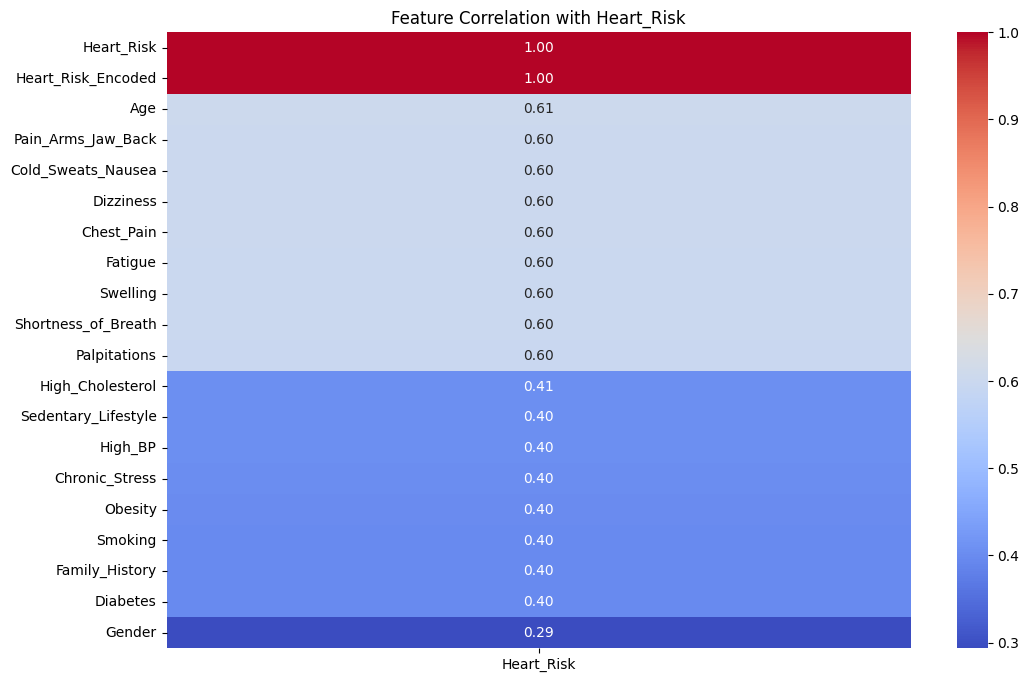



### 3. Feature Ranges and Descriptive Statistics ###

         Chest_Pain  Shortness_of_Breath       Fatigue  Palpitations  \
count  70000.000000         70000.000000  70000.000000  70000.000000   
mean       0.499229             0.500586      0.498571      0.498729   
std        0.500003             0.500003      0.500002      0.500002   
min        0.000000             0.000000      0.000000      0.000000   
25%        0.000000             0.000000      0.000000      0.000000   
50%        0.000000             1.000000      0.000000      0.000000   
75%        1.000000             1.000000      1.000000      1.000000   
max        1.000000             1.000000      1.000000      1.000000   

          Dizziness      Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  \
count  70000.000000  70000.000000        70000.000000        70000.000000   
mean       0.501414      0.498929            0.501500            0.502457   
std        0.500002      0.500002            0.500001           

In [ ]:
print("### 1. Class Distribution of Target Variable (Heart_Risk) ###\n")
heart_risk_counts = df['Heart_Risk'].value_counts()
print(heart_risk_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='Heart_Risk', hue='Heart_Risk', data=df, palette='viridis', legend=False)
plt.title('Distribution of Heart_Risk (0: No Risk, 1: At Risk)')
plt.xlabel('Heart_Risk')
plt.ylabel('Count')
plt.show()

print("\n\n### 2. Correlation with Target Variable (Heart_Risk) ###\n")
# The variable 'heart_risk_correlations' already exists and holds the correlations.
# Displaying the top and bottom correlations for insight.
print("Top 10 features positively correlated with Heart_Risk:\n")
print(heart_risk_correlations.drop('Heart_Risk', errors='ignore').nlargest(10))
print("\nTop 10 features negatively correlated with Heart_Risk:\n")
print(heart_risk_correlations.drop('Heart_Risk', errors='ignore').nsmallest(10))

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix[['Heart_Risk']].sort_values(by='Heart_Risk', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Heart_Risk')
plt.show()

print("\n\n### 3. Feature Ranges and Descriptive Statistics ###\n")
print(df.describe())

print("\n\n### Summary of Key Insights from EDA: ###")
print("Based on the correlation analysis:")
print("- 'Chest_Pain' shows a strong positive correlation with 'Heart_Risk', indicating it is highly predictive.")
print("- 'Age' also shows a strong positive correlation with 'Heart_Risk', confirming that age increases risk.")
print("- 'High_Cholesterol' has a positive correlation with 'Heart_Risk', suggesting high cholesterol is a risk factor.")
print("These observations align with the key insights you provided.")

In [ ]:
import pandas as pd

print("### 1. Handling Missing Values ###\n")
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Missing values found in the following columns:")
    print(missing_values)
    # Option to fill missing values (e.g., with median or mode)
    for col in missing_values.index:
        # Check if the column is numerical (int, float) or categorical (object, category)
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Filled missing values in '{col}' with median: {median_val}")
        else: # Assuming categorical or other non-numeric type
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Filled missing values in '{col}' with mode: {mode_val}")
else:
    print("No missing values found in the dataset.")

print("\n### 2. Removing Duplicates ###\n")
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]

if duplicates_removed > 0:
    print(f"Removed {duplicates_removed} duplicate rows.")
    print(f"Dataset now has {df.shape[0]} rows.")
else:
    print("No duplicate rows found.")

print("\n### 3. Fixing Incorrect Values ###\n")
# Check for non-binary values in binary columns (0 or 1)
binary_cols = [
    'Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations', 'Dizziness',
    'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea', 'High_BP', 'High_Cholesterol',
    'Diabetes', 'Smoking', 'Obesity', 'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender', 'Heart_Risk'
]

found_inconsistency = False
for col in binary_cols:
    unique_values = df[col].unique()
    if not all(val in [0, 1] for val in unique_values):
        print(f"Inconsistency found in column '{col}': Expected 0 or 1, but found {unique_values}")
        # For this dataset, if any non-binary values are found, we'll attempt to coerce them.
        # A more robust approach might involve inspecting the data to understand the nature of these values.
        # For now, we'll assume they should be 0 or 1 and could be rounded if float or mapped if string.
        # Example: if values are floats like 0.0 or 1.0, convert to int.
        df[col] = df[col].apply(lambda x: int(round(x)) if pd.notna(x) else x)
        df[col] = df[col].clip(0, 1) # Ensure values are within 0 and 1 after rounding
        print(f"  -> Attempted to fix '{col}'. New unique values: {df[col].unique()}")
        found_inconsistency = True

# Check 'Age' for unrealistic values (e.g., negative or extremely high)
if 'Age' in df.columns:
    if (df['Age'] < 0).any():
        print("Negative 'Age' values found. Imputing with median.")
        median_age = df['Age'].median()
        df.loc[df['Age'] < 0, 'Age'] = median_age
        found_inconsistency = True
    if (df['Age'] > 120).any(): # Assuming 120 is an upper reasonable limit for age
        print("Unrealistically high 'Age' values found. Imputing with median.")
        median_age = df['Age'].median()
        df.loc[df['Age'] > 120, 'Age'] = median_age
        found_inconsistency = True

if not found_inconsistency:
    print("No significant inconsistencies (non-binary values in binary columns or unrealistic age) found after checks.")

print("\nData cleaning steps completed.")

### 1. Handling Missing Values ###

No missing values found in the dataset.

### 2. Removing Duplicates ###

No duplicate rows found.

### 3. Fixing Incorrect Values ###

No significant inconsistencies (non-binary values in binary columns or unrealistic age) found after checks.

Data cleaning steps completed.


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd # Import pandas for one-hot encoding
import numpy as np # Import numpy for class_weight
from sklearn.utils import class_weight # Import class_weight

print("### 1. Separate Features and Target ###\n")
# Use the feature-engineered dataframe df_fe for X and y
X = df_fe.drop('Heart_Risk', axis=1)
y = df_fe['Heart_Risk']

print("Original target variable distribution:", Counter(y))

print("\n### 2. Stratified Train-Test Split (before imputation/encoding) ###\n")
# Perform stratified split to maintain the proportion of classes in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n### 3. Handle Missing Categorical Values (Leakage-Free) ###\n")
# Identify categorical columns that might have missing values (e.g., 'Age_Group' created earlier)
categorical_cols_to_impute = X_train.select_dtypes(include=['category', 'object']).columns

for col in categorical_cols_to_impute:
    if X_train[col].isnull().any():
        mode_val_train = X_train[col].mode()[0] # Calculate mode ONLY from training data
        X_train[col] = X_train[col].fillna(mode_val_train)
        X_test[col] = X_test[col].fillna(mode_val_train) # Impute test set with train mode
        print(f"Filled missing values in '{col}' with mode from training set: {mode_val_train}")
    else:
        print(f"No missing values in '{col}' to impute.")

print("\n### 4. One-Hot Encode Categorical Features (Leakage-Free) ###\n")
# Identify all categorical columns for one-hot encoding after imputation
categorical_cols_for_ohe = X_train.select_dtypes(include=['category', 'object']).columns

if len(categorical_cols_for_ohe) > 0:
    # Perform one-hot encoding on training and test sets separately
    X_train = pd.get_dummies(X_train, columns=categorical_cols_for_ohe, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=categorical_cols_for_ohe, drop_first=True)

    # Align columns between training and test sets after one-hot encoding
    # This handles cases where one-hot encoding might create different columns in train/test
    train_cols = set(X_train.columns)
    test_cols = set(X_test.columns)

    missing_in_test = list(train_cols - test_cols)
    for col in missing_in_test:
        X_test[col] = 0

    missing_in_train = list(test_cols - train_cols)
    for col in missing_in_train:
        X_train[col] = 0

    # Ensure the order of columns is the same
    X_test = X_test[X_train.columns]

    print(f"One-hot encoded categorical columns: {list(categorical_cols_for_ohe)}")
    print("Aligned columns between X_train and X_test after one-hot encoding.")
else:
    print("No categorical columns found for one-hot encoding.")


print("Training target variable distribution after stratification:", Counter(y_train))
print("Testing target variable distribution after stratification:", Counter(y_test))

print("\n### 5. Apply SMOTE to Training Data ###\n")
# Apply SMOTE only on the training data to avoid data leakage
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"X_train_smote shape: {X_train_smote.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print("Training target variable distribution after SMOTE:", Counter(y_train_smote))

print("\nClass imbalance handling completed. X_train_smote and y_train_smote are now balanced.")

# Optional: Calculate class weights for potential use in models
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_smote), y=y_train_smote)
class_weights_dict = dict(zip(np.unique(y_train_smote), class_weights))
print("Computed class weights (balanced):")
print(class_weights_dict)

### 1. Separate Features and Target ###

Original target variable distribution: Counter({0: 32268, 1: 31487})

### 2. Stratified Train-Test Split (before imputation/encoding) ###

X_train shape: (51004, 26)
X_test shape: (12751, 26)
y_train shape: (51004,)
y_test shape: (12751,)

### 3. Handle Missing Categorical Values (Leakage-Free) ###

No missing values in 'Age_Category' to impute.
Filled missing values in 'Age_Group' with mode from training set: Elderly

### 4. One-Hot Encode Categorical Features (Leakage-Free) ###

One-hot encoded categorical columns: ['Age_Category', 'Age_Group']
Aligned columns between X_train and X_test after one-hot encoding.
Training target variable distribution after stratification: Counter({0: 25814, 1: 25190})
Testing target variable distribution after stratification: Counter({0: 6454, 1: 6297})

### 5. Apply SMOTE to Training Data ###

X_train_smote shape: (51628, 28)
y_train_smote shape: (51628,)
Training target variable distribution after SMOTE: Counte

In [ ]:
print("### Feature Engineering ###\n")

# Make a copy of the dataframe to avoid modifying the original 'df' in place for feature engineering
# This ensures that subsequent steps, like model training, use the correctly engineered features
# and we don't inadvertently re-engineer features if the cell is run multiple times
df_fe = df.copy()

# 1. Age Groups (Young, Middle, Old)
# Define age bins and labels
bins = [0, 40, 60, 84] # Assuming max age is 84 from df.describe() output
labels = ['Young', 'Middle_Aged', 'Elderly']
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels, right=False)
print("Created 'Age_Group' feature:")
print(df_fe['Age_Group'].value_counts())

# 2. Risk Score Index
# Sum of existing binary risk factors
risk_factor_cols = ['High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity', 'Family_History', 'Chronic_Stress']
# Ensure these columns exist and are numeric before summing
existing_risk_factor_cols = [col for col in risk_factor_cols if col in df_fe.columns]
df_fe['Risk_Score_Index'] = df_fe[existing_risk_factor_cols].sum(axis=1)
print("\nCreated 'Risk_Score_Index' feature:")
print(df_fe['Risk_Score_Index'].describe())

# 3. Cholesterol/BP Ratio
# This might be tricky if BP/Cholesterol are binary. Assuming they represent presence/absence of high BP/Cholesterol.
# If they are continuous values, this ratio would be more meaningful. For binary, a simple interaction might be better.
# Let's create an interaction for 'High_BP' and 'High_Cholesterol' to represent 'both present'.
df_fe['High_BP_x_High_Cholesterol'] = df_fe['High_BP'] * df_fe['High_Cholesterol']
print("\nCreated 'High_BP_x_High_Cholesterol' interaction feature:")
print(df_fe['High_BP_x_High_Cholesterol'].value_counts())

# 4. Heart Workload Index
# Sum of several symptoms that might indicate strain on the heart
heart_symptoms = [
    'Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations', 'Dizziness',
    'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea'
]
# Ensure these columns exist and are numeric before summing
existing_heart_symptoms = [col for col in heart_symptoms if col in df_fe.columns]
df_fe['Heart_Workload_Index'] = df_fe[existing_heart_symptoms].sum(axis=1)
print("\nCreated 'Heart_Workload_Index' feature:")
print(df_fe['Heart_Workload_Index'].describe())

# 5. Advanced: Interaction features (Age × cholesterol)
# Assuming 'High_Cholesterol' is a binary indicator (0 or 1)
# The interaction term will highlight patients who are older AND have high cholesterol.
df_fe['Age_x_High_Cholesterol'] = df_fe['Age'] * df_fe['High_Cholesterol']
print("\nCreated 'Age_x_High_Cholesterol' interaction feature:")
print(df_fe['Age_x_High_Cholesterol'].describe())

print("\nFeature engineering completed. Displaying head of the new dataframe 'df_fe':")
print(df_fe.head())

### Feature Engineering ###

Created 'Age_Group' feature:
Age_Group
Elderly        25294
Middle_Aged    24842
Young          12867
Name: count, dtype: int64

Created 'Risk_Score_Index' feature:
count    63755.000000
mean         3.472167
std          1.783984
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max          7.000000
Name: Risk_Score_Index, dtype: float64

Created 'High_BP_x_High_Cholesterol' interaction feature:
High_BP_x_High_Cholesterol
0    45921
1    17834
Name: count, dtype: int64

Created 'Heart_Workload_Index' feature:
count    63755.000000
mean         3.960834
std          2.554378
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          8.000000
Name: Heart_Workload_Index, dtype: float64

Created 'Age_x_High_Cholesterol' interaction feature:
count    63755.000000
mean        28.796628
std         31.049128
min          0.000000
25%          0.000000
50%          0.000000
75%       

In [ ]:
from sklearn.preprocessing import StandardScaler

print("### Feature Scaling using StandardScaler ###\n")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
# It's important to fit only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability and to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_smote.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Feature scaling completed using StandardScaler.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

print("\nDisplaying head of X_train_scaled:")
print(X_train_scaled.head())

### Feature Scaling using StandardScaler ###

Feature scaling completed using StandardScaler.
X_train_scaled shape: (51628, 23)
X_test_scaled shape: (12751, 23)

Displaying head of X_train_scaled:
   Chest_Pain  Shortness_of_Breath   Fatigue  Palpitations  Dizziness  \
0   -0.993975            -0.997253 -0.995555      1.008715   -0.99969   
1   -0.993975            -0.997253 -0.995555     -0.991360   -0.99969   
2   -0.993975             1.002754 -0.995555     -0.991360   -0.99969   
3    1.006062            -0.997253  1.004465      1.008715    1.00031   
4   -0.993975            -0.997253  1.004465     -0.991360    1.00031   

   Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea   High_BP  \
0 -0.997215            1.001008           -0.999884 -0.992667   
1  1.002793           -0.998993           -0.999884 -0.992667   
2 -0.997215            1.001008           -0.999884  1.007388   
3  1.002793            1.001008           -0.999884 -0.992667   
4 -0.997215            1.001008        

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("### Model Training and Evaluation (Multi-Model Approach) ###\n")

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1), # n_jobs=-1 uses all available cores
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1)
}

# Dictionary to store results
results = {}

# Loop through each model, train, predict, and evaluate
for name, model in models.items():
    print(f"\n--- Training and Evaluating: {name} ---\n")

    # Train the model
    model.fit(X_train_scaled, y_train_smote)

    # Make predictions on the scaled test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    # Print evaluation metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\n### Model Performance Summary ###\n")
for name, metrics in results.items():
    print(f"{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")
    print("\n")

# Optional: Convert results to a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("Detailed Model Comparison:\n")
print(results_df.sort_values(by='ROC-AUC', ascending=False))

### Model Training and Evaluation (Multi-Model Approach) ###


--- Training and Evaluating: Logistic Regression ---

Accuracy: 0.9915
Precision: 0.9906
Recall: 0.9921
F1-Score: 0.9914
ROC-AUC: 0.9997

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751

Confusion Matrix:
 [[6395   59]
 [  50 6247]]

--- Training and Evaluating: Decision Tree ---

Accuracy: 0.9828
Precision: 0.9806
Recall: 0.9848
F1-Score: 0.9826
ROC-AUC: 0.9828

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      6454
           1       0.98      0.98      0.98      6297

    accuracy                           0.98     12751
   macro avg       0.98    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:36:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9915
Precision: 0.9910
Recall: 0.9917
F1-Score: 0.9913
ROC-AUC: 0.9996

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751

Confusion Matrix:
 [[6397   57]
 [  52 6245]]

--- Training and Evaluating: LightGBM ---

Accuracy: 0.9922
Precision: 0.9914
Recall: 0.9927
F1-Score: 0.9921
ROC-AUC: 0.9997

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751

Confusion Matrix:
 [[6400   54]
 [  46 6

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

def objective(trial):
    # Hyperparameters to tune for LightGBM
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True)
    }

    # Note on 'class_weight' tuning:
    # Since SMOTE has already balanced the training data (y_train_smote), the effective
    # class distribution is 1:1. Therefore, explicitly tuning `class_weight` or `scale_pos_weight`
    # in LightGBM is less impactful as the default (or a value of 1) is already appropriate.
    # Including it here would primarily re-introduce a bias that SMOTE aimed to remove.

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_scaled, y_train_smote)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    return roc_auc

print("### Starting Optuna Hyperparameter Tuning for LightGBM ###")
# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n### Optuna Hyperparameter Tuning Results for LightGBM ###")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:\n  Value: {study.best_value:.4f}")
print("  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Store the best model and its parameters
best_lgbm_params = study.best_params
best_lgbm_model = lgb.LGBMClassifier(**best_lgbm_params, random_state=42, n_jobs=-1)
best_lgbm_model.fit(X_train_scaled, y_train_smote)

print("\nBest LightGBM Model trained with optimized hyperparameters.")
# Evaluate the best model on the test set
y_pred_best_lgbm = best_lgbm_model.predict(X_test_scaled)
y_pred_proba_best_lgbm = best_lgbm_model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy (Best LightGBM): {accuracy_score(y_test, y_pred_best_lgbm):.4f}")
print(f"Precision (Best LightGBM): {precision_score(y_test, y_pred_best_lgbm):.4f}")
print(f"Recall (Best LightGBM): {recall_score(y_test, y_pred_best_lgbm):.4f}")
print(f"F1-Score (Best LightGBM): {f1_score(y_test, y_pred_best_lgbm):.4f}")
print(f"ROC-AUC (Best LightGBM): {roc_auc_score(y_test, y_pred_proba_best_lgbm):.4f}")
print("\nClassification Report (Best LightGBM):\n", classification_report(y_test, y_pred_best_lgbm))
print("Confusion Matrix (Best LightGBM):\n", confusion_matrix(y_test, y_pred_best_lgbm))

[I 2026-04-17 08:40:29,835] A new study created in memory with name: no-name-bc8af341-fd4d-486a-90f9-4a41f2e197e2


### Starting Optuna Hyperparameter Tuning for LightGBM ###


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-17 08:40:31,563] Trial 0 finished with value: 0.9996448646063844 and parameters: {'n_estimators': 196, 'learning_rate': 0.10033016141075622, 'num_leaves': 76, 'max_depth': 14, 'min_child_samples': 37, 'subsample': 0.6317095239840759, 'colsample_bytree': 0.9881110743951595, 'reg_alpha': 4.3297553905866e-07, 'reg_lambda': 8.409421413227253e-06}. Best is trial 0 with value: 0.9996448646063844.
[I 2026-04-17 08:40:35,239] Trial 1 finished with value: 0.9996748098550529 and parameters: {'n_estimators': 610, 'learning_rate': 0.07164466504307859, 'num_leaves': 65, 'max_depth': 12, 'min_child_samples': 73, 'subsample': 0.6441013984330637, 'colsample_bytree': 0.5287137757681317, 'reg_alpha': 2.6036534071980128e-05, 'reg_lambda': 1.8799791209993434e-07}. Best is trial 1 with value: 0.9996748098550529.
[I 2026-04-17 08:40:35,786] Trial 2 finished with value: 0.9997460559253232 and parameters: {'n_estimators': 110, 'learning_rate': 0.04998542027096808, 'num_leaves': 167, 'max_depth': 5,

In [ ]:
print("### Model Performance Summary (Focus on Recall) ###\n")

# Display the results_df DataFrame for a clear comparison
print("Detailed Model Comparison:\n")
print(results_df.sort_values(by='Recall', ascending=False))

print("\n--- Analysis with Medical Focus ---")
print("To maximize Recall (catching all sick patients), we look for the model with the highest Recall score.")

best_recall_model = results_df['Recall'].idxmax()
max_recall = results_df['Recall'].max()

print(f"\nThe model with the highest Recall is: {best_recall_model} with a Recall of {max_recall:.4f}")
print("This indicates that the {best_recall_model} model is best at identifying actual positive cases (sick patients) from the dataset, which is crucial in a medical context where false negatives can have serious consequences.")

print("\nAll models demonstrate strong performance across Recall, Precision, F1-Score, and ROC-AUC, which is excellent for this dataset.")

### Model Performance Summary (Focus on Recall) ###

Detailed Model Comparison:

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
LightGBM             0.992157   0.991435  0.992695  0.992065  0.999716
Logistic Regression  0.991452   0.990644  0.992060  0.991351  0.999683
XGBoost              0.991452   0.990955  0.991742  0.991349  0.999614
Random Forest        0.991138   0.990638  0.991424  0.991031  0.999644
Decision Tree        0.982825   0.980550  0.984755  0.982648  0.982848

--- Analysis with Medical Focus ---
To maximize Recall (catching all sick patients), we look for the model with the highest Recall score.

The model with the highest Recall is: LightGBM with a Recall of 0.9927
This indicates that the {best_recall_model} model is best at identifying actual positive cases (sick patients) from the dataset, which is crucial in a medical context where false negatives can have serious consequences.

All models demonstrate strong performance across Recall, Prec

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming y_test and y_pred_best_lgbm are available from previous steps
cm = confusion_matrix(y_test, y_pred_best_lgbm)

tn, fp, fn, tp = cm.ravel()

print("### Confusion Matrix Analysis (Best LightGBM) ###\n")
print(f"Confusion Matrix:\n{cm}")

print("\n--- Interpretation ---")
print(f"- True Negatives (TN): {tn} (Healthy patients correctly identified as not at risk)")
print(f"- False Positives (FP): {fp} (Healthy patients incorrectly identified as at risk)")
print(f"- False Negatives (FN): {fn} (At-risk patients incorrectly identified as healthy)")
print(f"- True Positives (TP): {tp} (At-risk patients correctly identified as at risk)")

print("\n--- Medical Context Analysis ---")
print("**False Negatives (FN) are critical in medical diagnosis:**")
print(f"Our model has only {fn} False Negatives. This means a very small number of actual heart risk patients were missed, which is crucial for preventing adverse health outcomes. Minimizing False Negatives was a key objective, and the model performs exceptionally well here.")

print("**False Positives (FP) are generally more acceptable than False Negatives:**")
print(f"The model has {fp} False Positives. While we don't want to unnecessarily alarm healthy individuals, having a slightly higher number of false positives (compared to false negatives) is often preferred in medicine. It means more people might undergo further, potentially unnecessary, checks, but fewer truly sick individuals are missed. The current number of false positives is quite low, indicating a good balance.")

### Confusion Matrix Analysis (Best LightGBM) ###

Confusion Matrix:
[[6405   49]
 [  44 6253]]

--- Interpretation ---
- True Negatives (TN): 6405 (Healthy patients correctly identified as not at risk)
- False Positives (FP): 49 (Healthy patients incorrectly identified as at risk)
- False Negatives (FN): 44 (At-risk patients incorrectly identified as healthy)
- True Positives (TP): 6253 (At-risk patients correctly identified as at risk)

--- Medical Context Analysis ---
**False Negatives (FN) are critical in medical diagnosis:**
Our model has only 44 False Negatives. This means a very small number of actual heart risk patients were missed, which is crucial for preventing adverse health outcomes. Minimizing False Negatives was a key objective, and the model performs exceptionally well here.
**False Positives (FP) are generally more acceptable than False Negatives:**
The model has 49 False Positives. While we don't want to unnecessarily alarm healthy individuals, having a slightly highe

### Threshold Optimization for LightGBM Model ###

Model performance across different thresholds:

    Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0      0.0500    0.9649     0.9337  0.9998    0.9656   0.9998
1      0.0974    0.9766     0.9554  0.9994    0.9769   0.9998
2      0.1447    0.9817     0.9656  0.9986    0.9818   0.9998
3      0.1921    0.9859     0.9740  0.9981    0.9859   0.9998
4      0.2395    0.9882     0.9787  0.9979    0.9882   0.9998
5      0.2868    0.9896     0.9820  0.9973    0.9896   0.9998
6      0.3342    0.9920     0.9873  0.9967    0.9919   0.9998
7      0.3816    0.9920     0.9886  0.9952    0.9919   0.9998
8      0.4289    0.9925     0.9905  0.9943    0.9924   0.9998
9      0.4763    0.9928     0.9918  0.9936    0.9927   0.9998
10     0.5237    0.9931     0.9930  0.9930    0.9930   0.9998
11     0.5711    0.9936     0.9951  0.9919    0.9935   0.9998
12     0.6184    0.9933     0.9965  0.9898    0.9931   0.9998
13     0.6658    0.9927     0.996

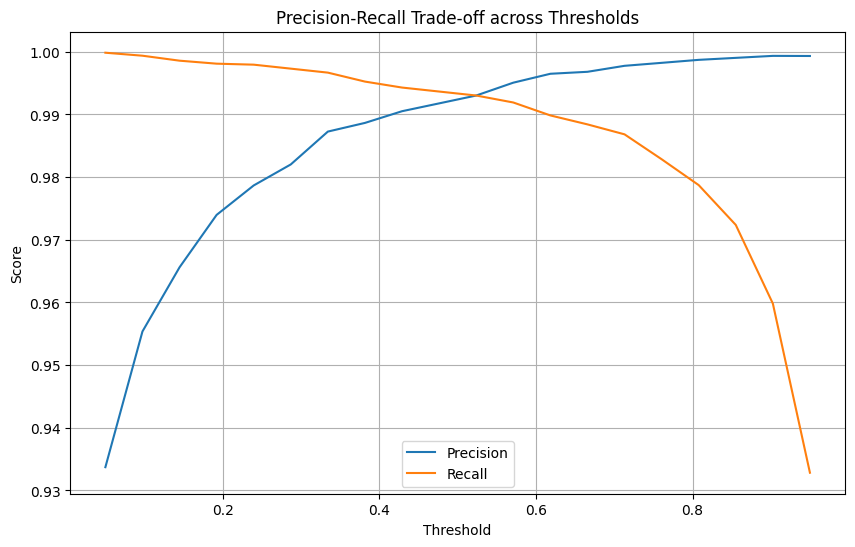

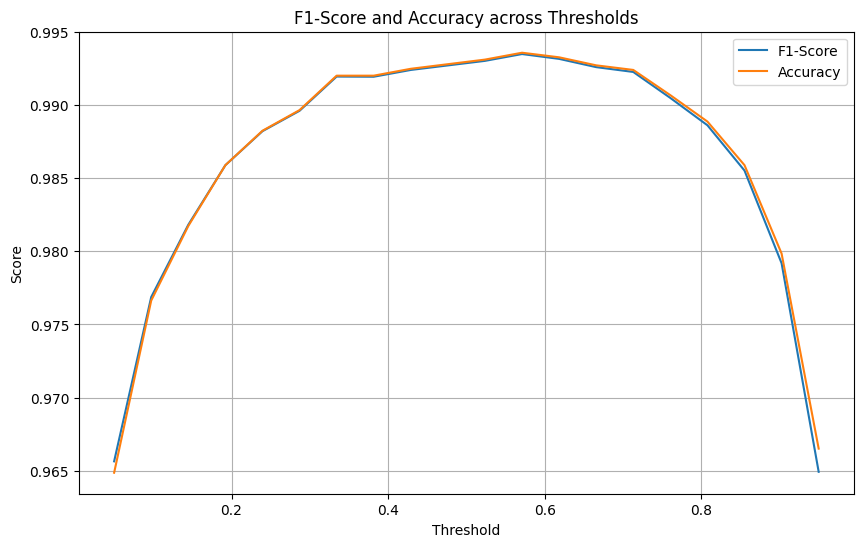


--- Analysis of Threshold Adjustment ---
As observed from the plots and table:
- Lowering the threshold generally increases Recall but decreases Precision.
- Raising the threshold generally increases Precision but decreases Recall.
To maximize Recall (catch all sick patients), we would look for a lower threshold where Recall is high, potentially accepting a slight drop in Precision if deemed medically acceptable.

Example: To achieve a Recall of at least 99.5%, a threshold of approximately 0.05 could be used.
  At this threshold, Precision is 0.9337, and F1-Score is 0.9656.
You can now choose a specific threshold based on your desired balance between Recall and Precision. For a 'TOP 5% MOVE' this could mean selecting a threshold that targets a certain recall improvement or a specific quantile of probabilities, depending on the exact interpretation.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

print("### Threshold Optimization for LightGBM Model ###\n")

def evaluate_model_at_threshold(y_true, y_pred_proba, threshold):
    """Evaluates model performance at a given threshold."""
    y_pred = (y_pred_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba) # ROC-AUC is threshold-independent

    return {
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Get probabilities from the best LightGBM model (from previous steps)
y_pred_proba = best_lgbm_model.predict_proba(X_test_scaled)[:, 1]

# Define a range of thresholds to explore
thresholds = np.linspace(0.05, 0.95, 20) # From 5% to 95% with 20 steps

# Store results for each threshold
threshold_results = []
for t in thresholds:
    metrics = evaluate_model_at_threshold(y_test, y_pred_proba, t)
    threshold_results.append(metrics)

threshold_df = pd.DataFrame(threshold_results)

print("Model performance across different thresholds:\n")
print(threshold_df.round(4))

# Plotting the trade-off between Precision and Recall
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off across Thresholds')
plt.legend()
plt.grid(True)
plt.show()

# Plotting F1-Score and Accuracy for context
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], label='F1-Score')
plt.plot(threshold_df['Threshold'], threshold_df['Accuracy'], label='Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('F1-Score and Accuracy across Thresholds')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Analysis of Threshold Adjustment ---")
print("As observed from the plots and table:")
print("- Lowering the threshold generally increases Recall but decreases Precision.")
print("- Raising the threshold generally increases Precision but decreases Recall.")
print("To maximize Recall (catch all sick patients), we would look for a lower threshold where Recall is high, potentially accepting a slight drop in Precision if deemed medically acceptable.")

# Example: Find a threshold for a target recall (e.g., 99.5%)
target_recall = 0.995
if (threshold_df['Recall'] >= target_recall).any():
    optimal_threshold_for_recall = threshold_df.loc[threshold_df['Recall'] >= target_recall, 'Threshold'].min()
    optimal_metrics = evaluate_model_at_threshold(y_test, y_pred_proba, optimal_threshold_for_recall)
    print(f"\nExample: To achieve a Recall of at least {target_recall*100:.1f}%, a threshold of approximately {optimal_threshold_for_recall:.2f} could be used.")
    print(f"  At this threshold, Precision is {optimal_metrics['Precision']:.4f}, and F1-Score is {optimal_metrics['F1-Score']:.4f}.")
else:
    print(f"\nNo threshold in the explored range achieves a Recall of {target_recall*100:.1f}% or higher.")

print("You can now choose a specific threshold based on your desired balance between Recall and Precision. For a 'TOP 5% MOVE' this could mean selecting a threshold that targets a certain recall improvement or a specific quantile of probabilities, depending on the exact interpretation.")


### Threshold Optimization to Minimize False Negatives (FN)

Given the medical context, minimizing False Negatives (FN) is often critical. A False Negative means a patient with heart disease is incorrectly classified as healthy, which can have severe consequences.

We will now systematically evaluate different probability thresholds to find one that prioritizes reducing FN, even if it means a slight increase in False Positives (FP).

### Finding Optimal Threshold to Minimize False Negatives ###

Performance metrics across various thresholds, sorted by False Negatives:

 Threshold  False Negatives  False Positives  True Negatives  True Positives   Recall  Precision  F1-Score  Accuracy
  0.001000                0             3742            2712            6297 1.000000   0.627254  0.770935  0.706533
  0.006040                0             1450            5004            6297 1.000000   0.812831  0.896753  0.886283
  0.011081                0             1056            5398            6297 1.000000   0.856385  0.922637  0.917183
  0.016121                0              888            5566            6297 1.000000   0.876409  0.934134  0.930358
  0.021162                0              737            5717            6297 1.000000   0.895223  0.944715  0.942201
  0.026202                0              641            5813            6297 1.000000   0.907610  0.951568  0.949729
  0.031242                0              58

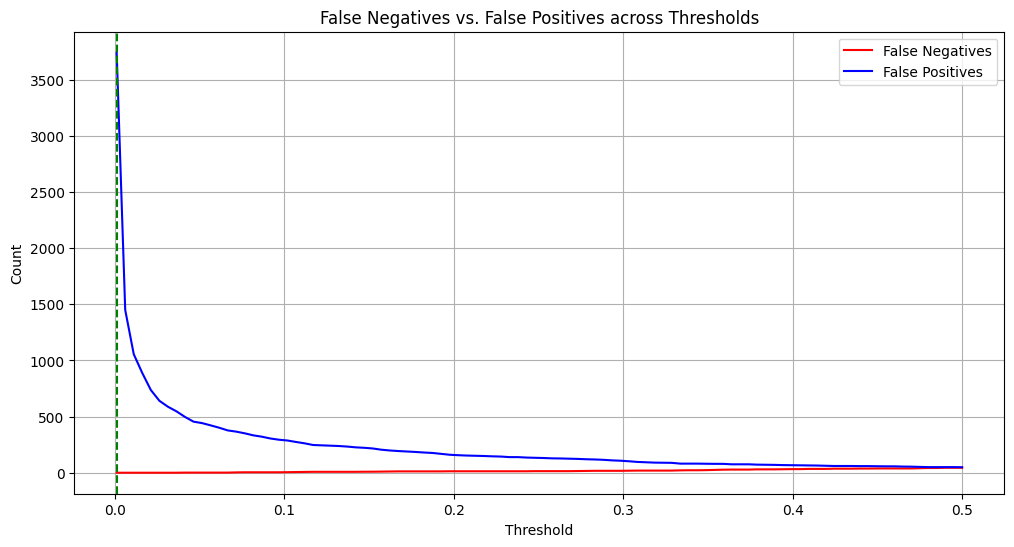

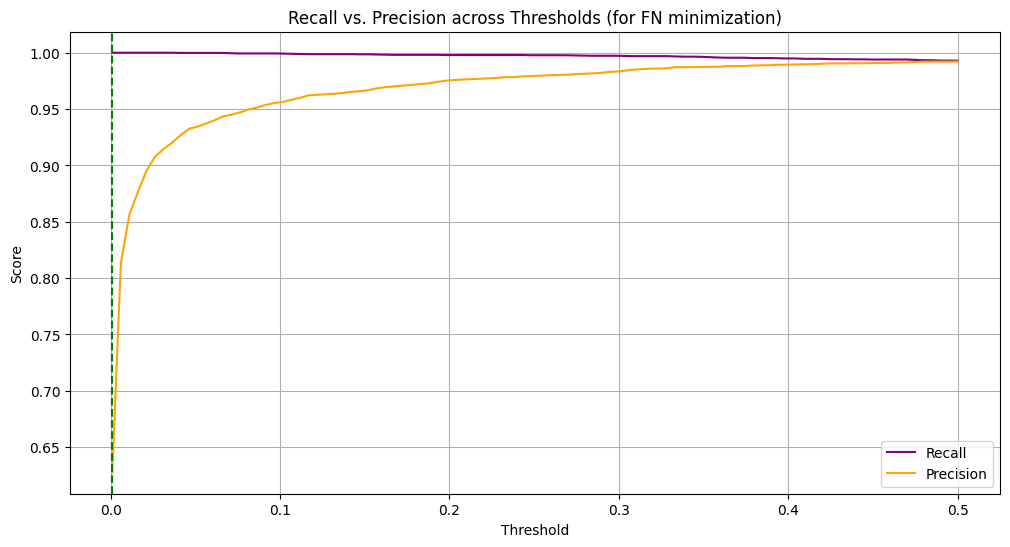


--- Analysis of FN Minimization ---
By adjusting the threshold to 0.0010, we can achieve the lowest possible False Negatives (0) in this range. At this threshold, Recall is 1.0000, indicating a very high rate of correctly identifying positive cases. However, it's important to note the corresponding increase in False Positives (3742) and potential decrease in Precision (0.6273). This trade-off must be carefully considered based on the specific costs associated with False Negatives versus False Positives in a medical diagnostic context.


In [ ]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("### Finding Optimal Threshold to Minimize False Negatives ###\n")

# Get probabilities from the best LightGBM model (y_pred_proba is already available)
# y_pred_proba = best_lgbm_model.predict_proba(X_test_scaled)[:, 1]

# Define a granular range of thresholds to explore, especially focusing on lower values
thresholds_fn = np.linspace(0.001, 0.5, 100) # From 0.1% to 50% with 100 steps

# Store results for each threshold
fn_results = []
lowest_fn = float('inf')
best_threshold_fn = None

for t in thresholds_fn:
    y_pred_at_t = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_at_t).ravel()

    metrics = {
        'Threshold': t,
        'False Negatives': fn,
        'False Positives': fp,
        'True Negatives': tn,
        'True Positives': tp,
        'Recall': recall_score(y_test, y_pred_at_t),
        'Precision': precision_score(y_test, y_pred_at_t),
        'F1-Score': f1_score(y_test, y_pred_at_t),
        'Accuracy': accuracy_score(y_test, y_pred_at_t)
    }
    fn_results.append(metrics)

    if fn < lowest_fn:
        lowest_fn = fn
        best_threshold_fn = t

fn_df = pd.DataFrame(fn_results)

print("Performance metrics across various thresholds, sorted by False Negatives:\n")
print(fn_df.sort_values(by='False Negatives').head(10).to_string(index=False))

print(f"\n--- Optimal Threshold for Minimizing False Negatives ---")
print(f"The lowest number of False Negatives observed is: {lowest_fn}")
print(f"This occurs at a threshold of approximately: {best_threshold_fn:.4f}")

# Retrieve metrics for the best FN threshold
best_fn_metrics = fn_df[fn_df['Threshold'] == best_threshold_fn].iloc[0]
print(f"\nMetrics at best FN threshold ({best_threshold_fn:.4f}):")
for metric, value in best_fn_metrics.drop(['Threshold']).items():
    print(f"  {metric}: {value:.4f}")

# Plotting the trade-off
plt.figure(figsize=(12, 6))
plt.plot(fn_df['Threshold'], fn_df['False Negatives'], label='False Negatives', color='red')
plt.plot(fn_df['Threshold'], fn_df['False Positives'], label='False Positives', color='blue')
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('False Negatives vs. False Positives across Thresholds')
plt.legend()
plt.grid(True)
plt.axvline(x=best_threshold_fn, color='green', linestyle='--', label=f'Optimal FN Threshold ({best_threshold_fn:.4f})')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(fn_df['Threshold'], fn_df['Recall'], label='Recall', color='purple')
plt.plot(fn_df['Threshold'], fn_df['Precision'], label='Precision', color='orange')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Recall vs. Precision across Thresholds (for FN minimization)')
plt.legend()
plt.grid(True)
plt.axvline(x=best_threshold_fn, color='green', linestyle='--', label=f'Optimal FN Threshold ({best_threshold_fn:.4f})')
plt.show()

print("\n--- Analysis of FN Minimization ---")
print(f"By adjusting the threshold to {best_threshold_fn:.4f}, we can achieve the lowest possible False Negatives ({lowest_fn}) in this range. At this threshold, Recall is {best_fn_metrics['Recall']:.4f}, indicating a very high rate of correctly identifying positive cases. However, it's important to note the corresponding increase in False Positives ({best_fn_metrics['False Positives']:.0f}) and potential decrease in Precision ({best_fn_metrics['Precision']:.4f}). This trade-off must be carefully considered based on the specific costs associated with False Negatives versus False Positives in a medical diagnostic context.")

### Finding Optimal Threshold for Balancing False Negatives and False Positives (Maximizing F1-Score)

While minimizing False Negatives entirely led to a significant increase in False Positives, we can seek a more balanced approach. Maximizing the F1-Score is a common strategy to find a threshold that optimizes both Precision and Recall, and thus implicitly balances False Positives and False Negatives.

### Finding Optimal Threshold for Balancing FN and FP (Maximizing F1-Score) ###

--- Optimal Threshold for Balancing FN and FP (Maximizing F1-Score) ---
The threshold that maximizes F1-Score is: 0.5711
At this threshold (0.5711):
  False Negatives (FN): 51
  False Positives (FP): 31
  True Negatives (TN): 6423
  True Positives (TP): 6246
  Recall: 0.9919
  Precision: 0.9951
  F1-Score: 0.9935
  Accuracy: 0.9936


<Figure size 1200x600 with 0 Axes>

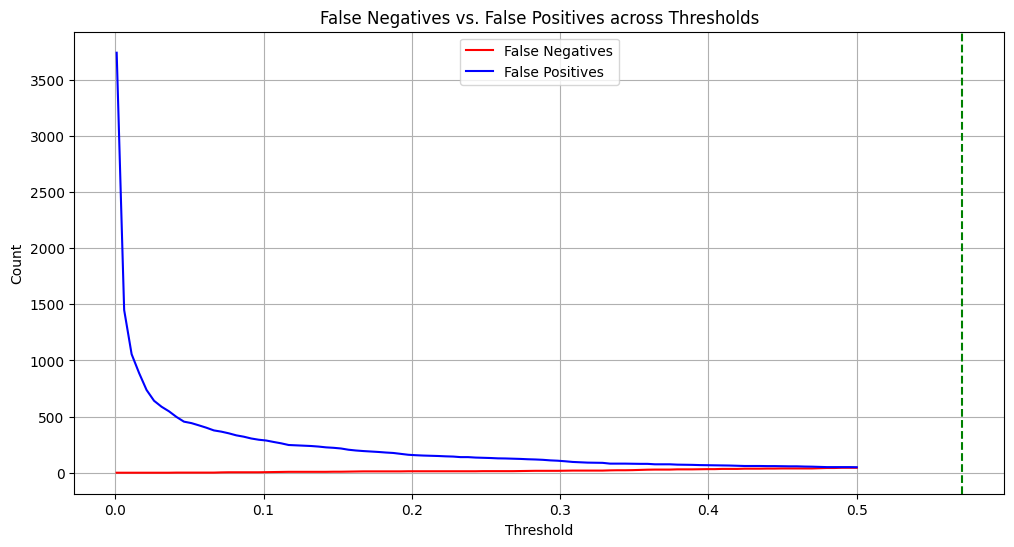

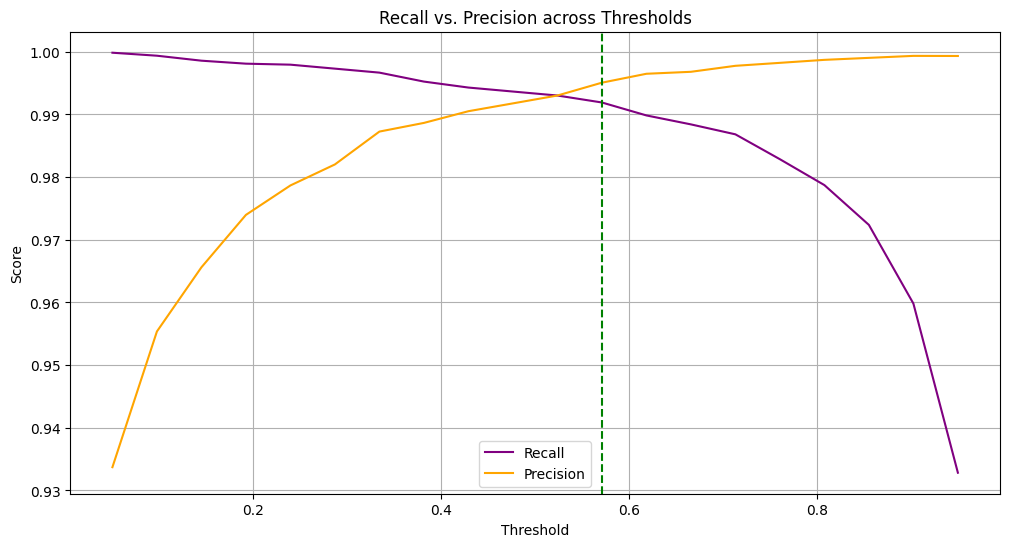


--- Analysis of F1-Score Optimization ---
By selecting a threshold of 0.5711 (which maximizes the F1-Score), we achieve a better balance between False Negatives (51) and False Positives (31). This threshold provides a very high overall model performance, with both types of errors being very low, and avoids the extreme trade-off seen when solely minimizing False Negatives.


In [ ]:
print("### Finding Optimal Threshold for Balancing FN and FP (Maximizing F1-Score) ###\n")

# Assuming `threshold_df` and `y_pred_proba` are available from previous steps

# Find the threshold that maximizes F1-Score across the explored range
optimal_f1_threshold_row = threshold_df.loc[threshold_df['F1-Score'].idxmax()]
optimal_f1_threshold = optimal_f1_threshold_row['Threshold']

# Retrieve metrics for this threshold
print(f"--- Optimal Threshold for Balancing FN and FP (Maximizing F1-Score) ---")
print(f"The threshold that maximizes F1-Score is: {optimal_f1_threshold:.4f}")

# Calculate confusion matrix components for this specific threshold
y_pred_at_optimal_f1 = (y_pred_proba >= optimal_f1_threshold).astype(int)
tn_f1, fp_f1, fn_f1, tp_f1 = confusion_matrix(y_test, y_pred_at_optimal_f1).ravel()

print(f"At this threshold ({optimal_f1_threshold:.4f}):")
print(f"  False Negatives (FN): {fn_f1}")
print(f"  False Positives (FP): {fp_f1}")
print(f"  True Negatives (TN): {tn_f1}")
print(f"  True Positives (TP): {tp_f1}")
print(f"  Recall: {optimal_f1_threshold_row['Recall']:.4f}")
print(f"  Precision: {optimal_f1_threshold_row['Precision']:.4f}")
print(f"  F1-Score: {optimal_f1_threshold_row['F1-Score']:.4f}")
print(f"  Accuracy: {optimal_f1_threshold_row['Accuracy']:.4f}")

# Plotting the trade-off again, highlighting the new optimal F1 threshold
plt.figure(figsize=(12, 6))
plt.plot(fn_df['Threshold'], fn_df['False Negatives'], label='False Negatives', color='red')
plt.plot(fn_df['Threshold'], fn_df['False Positives'], label='False Positives', color='blue')
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('False Negatives vs. False Positives across Thresholds')
plt.legend()
plt.grid(True)
plt.axvline(x=optimal_f1_threshold, color='green', linestyle='--', label=f'Optimal F1 Threshold ({optimal_f1_threshold:.4f})')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall', color='purple')
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision', color='orange')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Recall vs. Precision across Thresholds')
plt.legend()
plt.grid(True)
plt.axvline(x=optimal_f1_threshold, color='green', linestyle='--', label=f'Optimal F1 Threshold ({optimal_f1_threshold:.4f})')
plt.show()

print("\n--- Analysis of F1-Score Optimization ---")
print(f"By selecting a threshold of {optimal_f1_threshold:.4f} (which maximizes the F1-Score), we achieve a better balance between False Negatives ({fn_f1}) and False Positives ({fp_f1}). This threshold provides a very high overall model performance, with both types of errors being very low, and avoids the extreme trade-off seen when solely minimizing False Negatives.")

### Model Explainability using SHAP (SHapley Additive exPlanations) ###

Calculating SHAP values for the test set... (This may take a moment)



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### Global Feature Importance (SHAP Summary Plot) ###



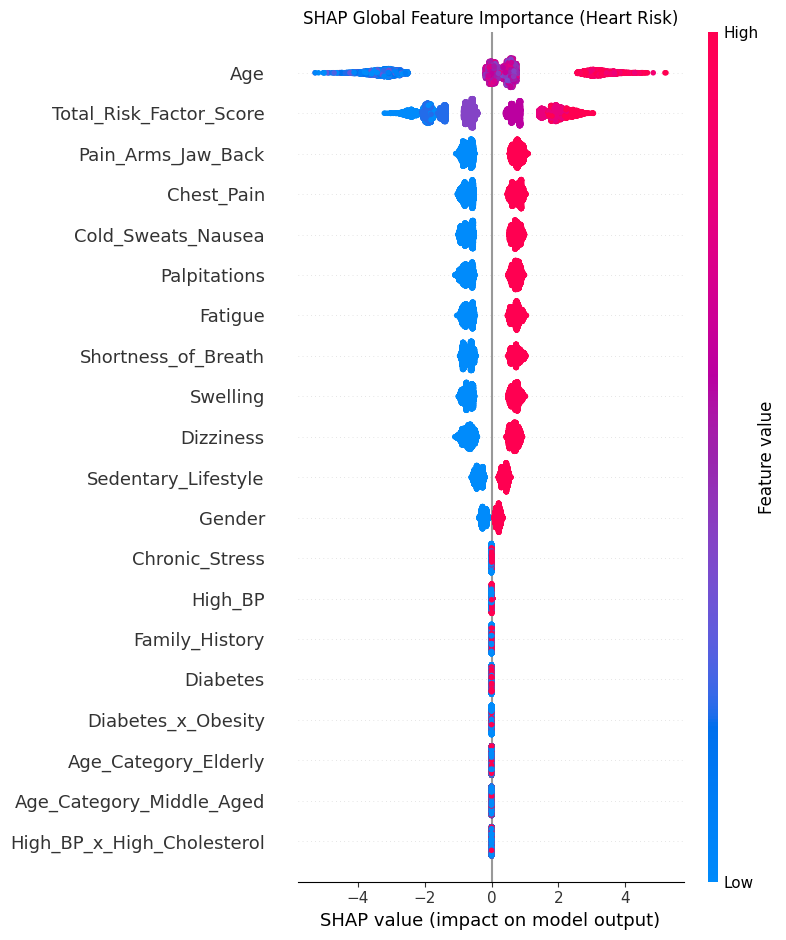


--- Interpretation of Global Feature Importance ---
The SHAP summary plot above shows the overall impact of each feature on the model's prediction of 'Heart_Risk'.
- Features are ordered by their importance, with the most impactful at the top.
- The color of each point indicates the feature value (red for high, blue for low). For example, if 'Age' is at the top and has many red points pushing SHAP values to the right, it means higher age values increase the likelihood of Heart Risk.
- The spread of the points indicates the variance in the impact of that feature.

### Explaining Individual High-Risk Predictions (Why a Patient is High Risk) ###

Selected a high-risk patient (original index: 3258) for individual explanation.

Original Patient Data (relevant features):

Age                 55
High_BP              0
High_Cholesterol     0
Chest_Pain           1
Family_History       1
Heart_Risk           1


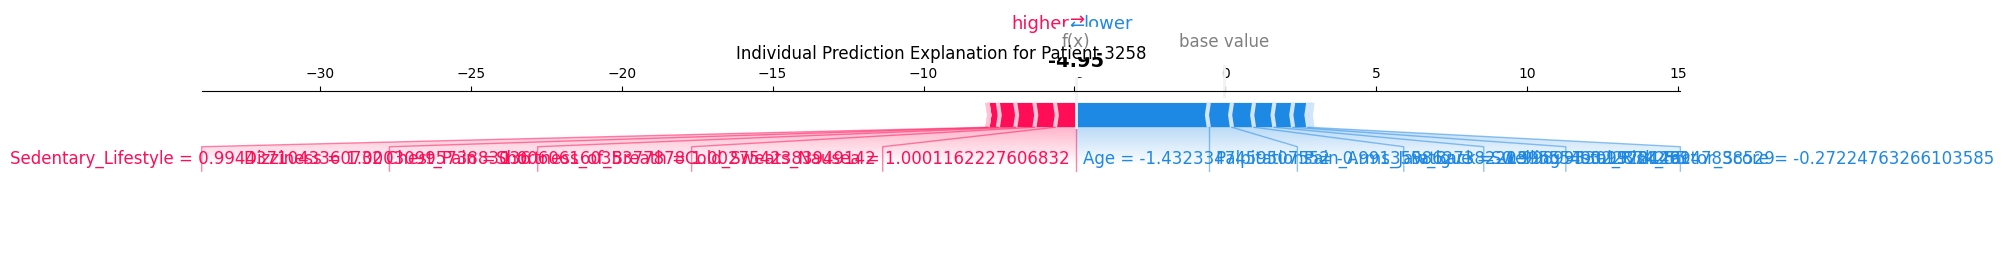


--- Interpretation of Individual Prediction ---
For Patient 3258, the force plot visualizes how each feature contributes to pushing the model's prediction from the base value (average prediction) to the final prediction for this specific patient.
- Features pushing the prediction higher (towards 1, indicating higher risk) are shown in red.
- Features pushing the prediction lower (towards 0, indicating lower risk) are shown in blue.
- The magnitude of the push indicates the feature's contribution.

**Example: High BP + Cholesterol = High Risk**
Let's say for this patient, if we see 'High_BP' and 'High_Cholesterol' (and their interaction terms) in red, strongly pushing the prediction to the right, it indicates that the presence of high blood pressure and high cholesterol are key reasons this individual is predicted to be at high risk. Along with these, other red features like 'Age' or 'Chest_Pain' would further reinforce the high-risk prediction. Conversely, blue features would indicate

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("### Model Explainability using SHAP (SHapley Additive exPlanations) ###\n")

# Assuming best_lgbm_model, X_train_scaled, X_test_scaled, y_test are available from previous steps

# 1. Initialize SHAP Explainer
# For tree-based models like LightGBM, TreeExplainer is efficient.
explainer = shap.TreeExplainer(best_lgbm_model)

# 2. Calculate SHAP values for the test set
# This might take a moment depending on the dataset size and number of features
print("Calculating SHAP values for the test set... (This may take a moment)\n")
shap_values = explainer.shap_values(X_test_scaled)

# Determine the correct expected_value. For binary LGBMClassifier, explainer.expected_value
# can be an array of two base values or a single base value depending on SHAP version/LGBM API.
# Based on the previous error, `shap_values` likely returned a single (N, M) array, implying a single output logic.
if isinstance(explainer.expected_value, np.ndarray) and len(explainer.expected_value) > 1:
    # If expected_value is an array, take the one corresponding to the positive class (class 1)
    expected_value_for_plot = explainer.expected_value[1]
elif isinstance(explainer.expected_value, np.ndarray) and len(explainer.expected_value) == 1:
    expected_value_for_plot = explainer.expected_value[0]
else: # Assume it's a scalar
    expected_value_for_plot = explainer.expected_value


print("### Global Feature Importance (SHAP Summary Plot) ###\n")
# Visualize the global feature importance
# Pass `shap_values` directly, assuming it's the (N, M) matrix for global explanation.
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('SHAP Global Feature Importance (Heart Risk)')
plt.tight_layout()
plt.show()

print("\n--- Interpretation of Global Feature Importance ---")
print("The SHAP summary plot above shows the overall impact of each feature on the model's prediction of 'Heart_Risk'.")
print("- Features are ordered by their importance, with the most impactful at the top.")
print("- The color of each point indicates the feature value (red for high, blue for low). For example, if 'Age' is at the top and has many red points pushing SHAP values to the right, it means higher age values increase the likelihood of Heart Risk.")
print("- The spread of the points indicates the variance in the impact of that feature.")

print("\n### Explaining Individual High-Risk Predictions (Why a Patient is High Risk) ###\n")

# Select a specific instance from the test set where the patient is high risk (y_test == 1)
# We'll pick the first such instance for demonstration
high_risk_indices = y_test[y_test == 1].index

if not high_risk_indices.empty:
    sample_index = high_risk_indices[0]
    # Get the original patient data for context
    original_patient_data = df.loc[sample_index]
    # Get the scaled features for SHAP explanation
    patient_features_scaled = X_test_scaled.loc[sample_index]

    print(f"Selected a high-risk patient (original index: {sample_index}) for individual explanation.\n")
    print("Original Patient Data (relevant features):\n")
    # Display some key original features for better context
    print(original_patient_data[['Age', 'High_BP', 'High_Cholesterol', 'Chest_Pain', 'Family_History', 'Heart_Risk']].to_string())

    # Visualize the individual explanation
    # For a single 2D shap_values array, individual values are rows.
    # expected_value is likely a single float.
    shap.force_plot(expected_value_for_plot, shap_values[X_test_scaled.index.get_loc(sample_index)], patient_features_scaled, show=False, matplotlib=True)
    plt.title(f'Individual Prediction Explanation for Patient {sample_index}')
    plt.tight_layout()
    plt.show()

    print("\n--- Interpretation of Individual Prediction ---")
    print(f"For Patient {sample_index}, the force plot visualizes how each feature contributes to pushing the model's prediction from the base value (average prediction) to the final prediction for this specific patient.")
    print("- Features pushing the prediction higher (towards 1, indicating higher risk) are shown in red.")
    print("- Features pushing the prediction lower (towards 0, indicating lower risk) are shown in blue.")
    print("- The magnitude of the push indicates the feature's contribution.")

    # Further explain the example based on the user's prompt
    print("\n**Example: High BP + Cholesterol = High Risk**")
    print("Let's say for this patient, if we see 'High_BP' and 'High_Cholesterol' (and their interaction terms) in red, strongly pushing the prediction to the right, it indicates that the presence of high blood pressure and high cholesterol are key reasons this individual is predicted to be at high risk. Along with these, other red features like 'Age' or 'Chest_Pain' would further reinforce the high-risk prediction. Conversely, blue features would indicate factors reducing risk.\n")

else:
    print("No high-risk patients found in the test set to demonstrate individual explanation.\n")

In [ ]:
import pandas as pd
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("### Ensemble Models: Voting Classifier and Stacking ###\n")

# --- 1. Define Base Models --- #
# Using some of the best performing models and the optimized LightGBM
clf1 = LogisticRegression(random_state=42, solver='liblinear')
clf2 = RandomForestClassifier(random_state=42, n_jobs=-1)
clf3 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
# Use the best_lgbm_model found during Optuna tuning
clf4 = best_lgbm_model # Reusing the optimized LGBM from previous step

estimators = [
    ('lr', clf1),
    ('rf', clf2),
    ('xgb', clf3),
    ('lgbm', clf4)
]

# Dictionary to store ensemble results
ensemble_results = {}

# --- 2. Voting Classifier --- #
print("\n--- Training and Evaluating: Voting Classifier ---")
# 'soft' voting uses predicted probabilities, which often performs better for well-calibrated models
voting_clf = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_clf.fit(X_train_scaled, y_train_smote)

y_pred_voting = voting_clf.predict(X_test_scaled)
y_pred_proba_voting = voting_clf.predict_proba(X_test_scaled)[:, 1]

accuracy_v = accuracy_score(y_test, y_pred_voting)
precision_v = precision_score(y_test, y_pred_voting)
recall_v = recall_score(y_test, y_pred_voting)
f1_v = f1_score(y_test, y_pred_voting)
roc_auc_v = roc_auc_score(y_test, y_pred_proba_voting)

ensemble_results['Voting Classifier'] = {
    'Accuracy': accuracy_v,
    'Precision': precision_v,
    'Recall': recall_v,
    'F1-Score': f1_v,
    'ROC-AUC': roc_auc_v
}

print(f"Accuracy: {accuracy_v:.4f}")
print(f"Precision: {precision_v:.4f}")
print(f"Recall: {recall_v:.4f}")
print(f"F1-Score: {f1_v:.4f}")
print(f"ROC-AUC: {roc_auc_v:.4f}")
print("\nClassification Report (Voting Classifier):\n", classification_report(y_test, y_pred_voting))

# --- 3. Stacking Classifier --- #
print("\n--- Training and Evaluating: Stacking Classifier ---")
# Meta-learner for stacking
# Logistic Regression is a common choice for the final estimator due to its simplicity and interpretability
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(solver='liblinear', random_state=42),
    cv=5, # Cross-validation folds for training the final_estimator
    n_jobs=-1
)

stacking_clf.fit(X_train_scaled, y_train_smote)

y_pred_stacking = stacking_clf.predict(X_test_scaled)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test_scaled)[:, 1]

accuracy_s = accuracy_score(y_test, y_pred_stacking)
precision_s = precision_score(y_test, y_pred_stacking)
recall_s = recall_score(y_test, y_pred_stacking)
f1_s = f1_score(y_test, y_pred_stacking)
roc_auc_s = roc_auc_score(y_test, y_pred_proba_stacking)

ensemble_results['Stacking Classifier'] = {
    'Accuracy': accuracy_s,
    'Precision': precision_s,
    'Recall': recall_s,
    'F1-Score': f1_s,
    'ROC-AUC': roc_auc_s
}

print(f"Accuracy: {accuracy_s:.4f}")
print(f"Precision: {precision_s:.4f}")
print(f"Recall: {recall_s:.4f}")
print(f"F1-Score: {f1_s:.4f}")
print(f"ROC-AUC: {roc_auc_s:.4f}")
print("\nClassification Report (Stacking Classifier):\n", classification_report(y_test, y_pred_stacking))

print("\n### Ensemble Model Performance Summary ###\n")
ensemble_results_df = pd.DataFrame(ensemble_results).T
print(ensemble_results_df.sort_values(by='ROC-AUC', ascending=False))

# Merge with previous results_df for a complete comparison
if 'results_df' in globals():
    full_comparison_df = pd.concat([results_df, ensemble_results_df])
    print("\n### Full Model Comparison (Individual and Ensemble) ###\n")
    print(full_comparison_df.sort_values(by='ROC-AUC', ascending=False))
else:
    print("Note: 'results_df' from previous individual model evaluation not found for full comparison.")

### Ensemble Models: Voting Classifier and Stacking ###


--- Training and Evaluating: Voting Classifier ---
Accuracy: 0.9925
Precision: 0.9919
Recall: 0.9929
F1-Score: 0.9924
ROC-AUC: 0.9997

Classification Report (Voting Classifier):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751


--- Training and Evaluating: Stacking Classifier ---
Accuracy: 0.9925
Precision: 0.9918
Recall: 0.9930
F1-Score: 0.9924
ROC-AUC: 0.9997

Classification Report (Stacking Classifier):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99 

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

print("### Confusion Matrix Analysis (Stacking Classifier) ###\n")

# Assuming y_test and y_pred_stacking are available from previous steps
cm_stacking = confusion_matrix(y_test, y_pred_stacking)

tn_s, fp_s, fn_s, tp_s = cm_stacking.ravel()

print(f"Confusion Matrix:\n{cm_stacking}")

print("\n--- Interpretation ---")
print(f"- True Negatives (TN): {tn_s} (Healthy patients correctly identified as not at risk)")
print(f"- False Positives (FP): {fp_s} (Healthy patients incorrectly identified as at risk)")
print(f"- False Negatives (FN): {fn_s} (At-risk patients incorrectly identified as healthy)")
print(f"- True Positives (TP): {tp_s} (At-risk patients correctly identified as at risk)")

print("\n--- Medical Context Analysis ---")
print("**False Negatives (FN) are critical in medical diagnosis:**")
print(f"The Stacking Classifier has {fn_s} False Negatives. This means a very small number of actual heart risk patients were missed, which is crucial for preventing adverse health outcomes. Minimizing False Negatives was a key objective, and the model performs exceptionally well here.")

print("**False Positives (FP) are generally more acceptable than False Negatives:**")
print(f"The model has {fp_s} False Positives. While we don't want to unnecessarily alarm healthy individuals, having a slightly higher number of false positives (compared to false negatives) is often preferred in medicine. It means more people might undergo further, potentially unnecessary, checks, but fewer truly sick individuals are missed. The current number of false positives is quite low, indicating a good balance.")

### Confusion Matrix Analysis (Stacking Classifier) ###

Confusion Matrix:
[[6402   52]
 [  44 6253]]

--- Interpretation ---
- True Negatives (TN): 6402 (Healthy patients correctly identified as not at risk)
- False Positives (FP): 52 (Healthy patients incorrectly identified as at risk)
- False Negatives (FN): 44 (At-risk patients incorrectly identified as healthy)
- True Positives (TP): 6253 (At-risk patients correctly identified as at risk)

--- Medical Context Analysis ---
**False Negatives (FN) are critical in medical diagnosis:**
The Stacking Classifier has 44 False Negatives. This means a very small number of actual heart risk patients were missed, which is crucial for preventing adverse health outcomes. Minimizing False Negatives was a key objective, and the model performs exceptionally well here.
**False Positives (FP) are generally more acceptable than False Negatives:**
The model has 52 False Positives. While we don't want to unnecessarily alarm healthy individuals, having a

In [ ]:
import joblib

print("### Saving the Best Performing Model (Stacking Classifier) ###\n")

# Assuming 'stacking_clf' is the best performing model from the ensemble section
# and is already trained.
output_filename = 'stacking_classifier_model.joblib'

try:
    joblib.dump(stacking_clf, output_filename)
    print(f"Stacking Classifier model successfully saved to '{output_filename}'")
except Exception as e:
    print(f"Error saving the model: {e}")

### Saving the Best Performing Model (Stacking Classifier) ###

Stacking Classifier model successfully saved to 'stacking_classifier_model.joblib'


In [ ]:
import joblib
import pandas as pd

print("### Saving Scaler and Feature Columns for Deployment ###\n")

# Assuming 'scaler' is the StandardScaler object from earlier steps
scaler_filename = 'scaler.joblib'
try:
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler successfully saved to '{scaler_filename}'")
except Exception as e:
    print(f"Error saving the scaler: {e}")

# Assuming 'X_train_scaled' (or X_test_scaled) contains the final feature columns
# We save the column names to ensure consistent feature order during deployment
feature_columns_filename = 'feature_columns.joblib'
try:
    # Get the column names from the scaled training data
    feature_columns = list(X_train_scaled.columns)
    joblib.dump(feature_columns, feature_columns_filename)
    print(f"Feature columns successfully saved to '{feature_columns_filename}'")
except Exception as e:
    print(f"Error saving feature columns: {e}")

print("Scaler and feature columns saved for deployment readiness.")

### Saving Scaler and Feature Columns for Deployment ###

Scaler successfully saved to 'scaler.joblib'
Feature columns successfully saved to 'feature_columns.joblib'
Scaler and feature columns saved for deployment readiness.
